# Gradient Boosting Regressor (GBR)

**Full feature set (no PCA)**

Author: Pete King

This notebook simply recreates the analysis from our grid search notebook using the optimized hyperparameters we found there.  It runs much faster without the grid search and we simply use it for convenience to reproduce results.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    make_scorer,
    r2_score,
    mean_absolute_error,
    root_mean_squared_error,
    mean_squared_error
)
from sklearn.model_selection import (
    TimeSeriesSplit,
    GridSearchCV
)
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.tree import plot_tree

from helpers import data_prep as dp

IMAGE_DIR = Path.cwd() / 'images'
DATA_DIR = Path.cwd().parent / 'data' / 'train-val-test'
TRAIN_DATA_FILE = DATA_DIR / 'train_BASE_DATA.csv'
VAL_DATA_FILE = DATA_DIR / 'val_BASE_DATA.csv'
TICKER = 'SPY'

## I. Import data


In [2]:
train_df = pd.read_csv(
    TRAIN_DATA_FILE,
    index_col='date',
    parse_dates=True
)
val_df = pd.read_csv(
    VAL_DATA_FILE,
    index_col='date',
    parse_dates=True
)

In [3]:
# Separate features from labels
# Include all input features, including return data
data_cols, _ = dp.get_X_y_cols(train_df, returns=True)
label_col = [TICKER + '_vol_target']
# Training set
X_train = train_df.dropna()[data_cols].astype(np.float32)
y_train = train_df.dropna()[label_col].astype(np.float32).values.reshape(-1,)
# Validation set
X_val = val_df.dropna()[data_cols].astype(np.float32)
y_val = val_df.dropna()[label_col].astype(np.float32).values.reshape(-1,)
# Define time series cross-validation split
ts_cv = TimeSeriesSplit(
    n_splits=3,
    test_size=252,
    gap=21
)

## II. Define model, fit to data, and evaluate performance

Here we select several hyperparameters that we chose using a grid search method.  The lower learning rate balances a larger number of estimators: the combined effect is similar taking a larger sample of weak learners and taking their average, introducing a greater degree of regularization.  The reduced number of features for each stage and reduced maximum tree depth both serve to reduce the model's tendency to overfit to training data and should improve generalization.

In [4]:
# Define model, metrics, and Grid Search for hyperparameter tuning
reg = GradientBoostingRegressor(
    loss='absolute_error',
    learning_rate=0.1,
    max_features='sqrt',
    max_depth=5,
    n_estimators= 100
)

In [5]:
reg.fit(X_train, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'absolute_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",5
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft

### Visualize performance; Check evaluation metrics

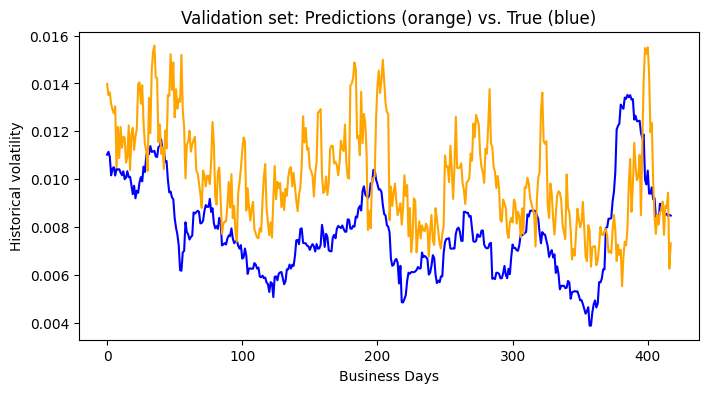

In [6]:
# Use the best estimator to make predictions on the validation set
# best = reg.best_estimator_
preds = reg.predict(X_val)
x = range(len(y_val))

fig = plt.figure(figsize=(8, 4))
ax = fig.subplots()
ax.set_title('Validation set: Predictions (orange) vs. True (blue)')
ax.set_ylabel('Historical volatility')
ax.set_xlabel('Business Days')
ax.plot(x, y_val, color='blue')
ax.plot(x, preds, color='orange')
fig.savefig(IMAGE_DIR / 'D-GBR-full')

In [7]:
print(f'MAE: {mean_absolute_error(y_val, preds)}')
print(f'R2: {r2_score(y_val, preds)}')

MAE: 0.002698292656196585
R2: -1.5890349246478346


Results for this run may not match exactly to the results from our grid search due to the stochastic nature of the model, but MAE and R-squared appear to be comparable to the run from our earlier notebook.  Visually, the predictions from this model look much more erratic compared to the predictions we got from our grid search model, which is a surprising result for which I can offer no convincing explanation.  Both this model and the model from our grid search tend to track relatively well with the true trend in volatility, as it spikes and recedes over time, albeit with considerable lag.

## III. Inspect model


In [8]:
feature_importances = list(
    zip(reg.feature_names_in_, reg.feature_importances_)
)
for feature, coef in sorted(feature_importances, key=lambda i: -i[1]):
    print(f'{feature}: {coef:2.3f}')

^VIX: 0.062
debt_to_GDP_chg: 0.044
real_GDP_chg: 0.040
XLY_vol-h: 0.040
^VXN: 0.035
unemployment_rate_chg: 0.034
^MOVE: 0.034
nominal_GDP_chg: 0.030
average_duration_of_unemployment_chg: 0.028
core_PCI_chg: 0.024
core_PCE_chg: 0.023
teenager_unemployment_rate_chg: 0.022
debt_interest_chg: 0.020
female_unemployment_rate_chg: 0.019
consumer_price_index_chg: 0.018
SPY_vol-h: 0.018
QQQ_vol-h: 0.016
producer_price_index_chg: 0.015
male_unemployment_rate_chg: 0.015
initial_jobless_claims_chg: 0.013
continued_jobless_claims_chg: 0.013
XLP_vol-h: 0.012
IEF_vol-h: 0.012
NG=F_vol-h: 0.012
adult_unemployment_rate_chg: 0.011
XLE_vol-h: 0.011
^HSI_vol-h: 0.011
SHY_vol-h: 0.011
BIL_vol-h: 0.011
HYG_vol-h: 0.011
XLRE_vol-h: 0.011
HG=F_vol-h: 0.011
GC=F_vol-h: 0.010
^GSPC_vol-h: 0.010
TLT_vol-h: 0.010
personal_consumption_expenditure_chg: 0.009
IWM_vol-h: 0.009
TIP_vol-h: 0.009
XLK_vol-h: 0.008
XLI_vol-h: 0.008
XLV_ret-h: 0.008
GLD_ret-h: 0.007
SPY_ret-h: 0.007
XLK_ret-h: 0.007
LQD_vol-h: 0.007
XLU_vo

Interestingly, we see a different ranking of feature importances on this run of the model, even though in theory it should be very close to our grid search.  Feature importances are very similar, with a similar set of features ranked highest on the list (e.g., ^VIX, real_GDP_chg, debt_to_GDP_chg).  Subtle differences are likely due to the stochastic nature of the model training process.